# Outlier detection algorithms

This notebook is dedicated to the implementation and testing of algorithms detecting outliers in a dataset.

## One-Class SVM (OC-SVM)

Let $\mathcal{X}$ be the space where data lives, and $d=\text{dim}(\mathcal{X})$. Data points are assumed to be the realization of a probability measure noted $\mathbb{P}$. We introduce the quantile function for a real-valued function $\lambda$ on measurable subsets $\mathcal{C}$ of $\mathcal{X}$: $U(\alpha)=\inf\limits_{C \in \mathcal{C}} \{\lambda (C)\backslash \mathbb{P}(C) \geq \alpha \}$, where $\alpha \in ]0, 1]$. We note $C(\alpha)$ the set that reaches the infimum for a level $\alpha$. $\lambda$ is usually the Lebesgue measure, in which case, it identifies to the generalized inverse distribution function. [1] describes an algorithm which finds regions close to $C(\alpha)$. A first idea could be to use the set separating hyperplanes $(H_{w, \rho})_{w \in \mathbb{R}^d, \rho \in \mathbb{R}}$ of general form: $H_{w, \rho}=\{x \backslash \, (w, x)_{\mathbb{R}^d} \geq \rho\}$, to find regions close to $C(\alpha)$. Excluding kernel parameters, the O-SVM has a single free parameter $\nu \in ]0, 1]$ representing the maximum portion of outliers in the dataset. Nonetheless, $\nu$ can be challenging to correctly tune.

For more generality, we should employ kernel machinery to map the data space $\mathcal{X}$ to the feature space $\mathcal{H}$ via a chosen feature map $\Phi$. Separating hyperplanes are then built in the feature space: $C_{w, \rho}=\{x \in \mathcal{X} \backslash \, (\Phi(x), w)_{\mathcal{H}}\geq \rho\}$; the major interest being that they translates into regions with nonlinear borders back in data space.

Take a dataset $x_1, \cdots, x_n \in \mathcal{X}$.

The objective is to present an algorithm that identifies a function $f$ taking the value $+1$ in 'small' regions that capture most of the data points and $-1$ elsewhere. The decision rule is to declare a point $x$ as an outlier if $f(x)=-1$. $f$ is chosen to be parameterized as $f(x)=\text{sgn}((w,x)-\rho)$, and the optimization problem to find optimal parameters $(w, \rho)$ is:


\begin{align*}
\min\limits_{w\in\mathcal{H}, \rho \in \mathbb{R}} & \frac12 ||w||_2^2 + \frac1{\nu n} \sum\limits_i \xi_i - \rho \\
\text{s.t} &\,\, (w, \Phi(x_i))\geq \rho-\xi_i \, \forall i \in \{1, \cdots ,n\},\\
& \xi_i \geq 0 \, \forall i \in \{1, \cdots ,n\}.
\end{align*}

If $\nu$ tends towards $0$, it becomes the hard margin problem $\forall i, \xi_i=0$, i.e., no outlier is allowed in the training dataset. It always remains feasible though, since $\rho$ is not lower-bounded. More precisely, $\nu$ is a upper bound on the number of outliers and a lower bound on the number of support vector.

The lagrangian of the primal problem is:
$$
\mathcal{L}(w, \rho, \alpha, \beta)=\frac12 ||w||_2^2 + \frac1{\nu n} \sum\limits_i \xi_i - \rho - \alpha\cdot (f(x_i)-\rho + \xi_i) - \beta \cdot \xi,
$$
where $\alpha, \beta\in\mathbb{R}^n$ are the Lagrange multipliers. Eliminating $\beta$, $w$ and $\rho$ yields the dual problem:
\begin{align*}
\min\limits_{\alpha \in \mathbb{R}^n} & \frac12 \sum\limits_{i,j=1}^n \alpha_i \alpha_j k(x_i, x_j) \\
\text{s.t} &\,\, 0\leq \alpha_i \leq \frac{1}{\nu n} \, \forall i \in \{1, \cdots ,n\},\\
& \sum\limits_{i=1}^n \alpha_i=1.
\end{align*}

Because the primal problem is convex, $(P) \iff (D)$.

After solving this problem, hyperplane parameters are $w=\sum\limits_{i=1}^n \alpha_i \Phi(x_i)$, and $\rho=(w, \Phi(x_i))=\sum\limits_{j=1}^n \alpha_j k(x_i, x_j)$ for any index $i$ such that $\alpha_i \in ]0, \frac1{\nu n}[$. We noted $k(x_i, x_j)=(\Phi(x_i), \Phi(x_j))_{\mathcal{H}}$. The complementary slackness of the KKT equations says that $O_i=\rho \iff 0<\alpha_i<\frac 1{\nu n}$. Those are the points that draw the margin between outlier and inlier. Also, $\alpha_i=0$ implies $O_i<\rho$, and $x_i$ is an outlier. Inversely, if $\alpha_i= \frac 1{\nu n}$, $x_i$ is an inlier because $O_i>\rho$.

### Quadratic Optimization algorithm

To solve this QP problem, one could use an off-the-shell solver, with time complexity scaling as $\mathcal{O}(n^3)$. Instead, [1] proposes an alternate version of *Sequential Minimal Optimization* (SMO), published in [2], to take advantage of the simplicity of the constraints and better scale with the size of dataset $n$.

We define the output of data $i$ as: $f(x_i)=O_i=\langle w, \Phi(x_i)\rangle$.

At initialisation, not index pair is selected yet. A fraction of entries chosen at random from $\alpha$ are set to $\frac1{\nu n}$, and the remaining entries are set to $0$. By the complementary condition, their Lagrange multiplier $\xi_i$ of the null entries are positive, meaning they are initialized as outliers since they lie out of the hyperplane. The initial $\rho$ is set to $\max\limits_{i}\{(O_i)_{i\in \llbracket 1, n\rrbracket}, \alpha_i>0\}$, with $O_i$ defined below.

You have to chose a pair of index $(i_1, i_2)$, and update iteratively $\alpha_{i_1}, \alpha_{i_2}$. This choice is made of heuristics that became increasingly sophisticated with time. I implement below the ones presented in [1], although they are largely outdated now.

Formally, $\alpha_{i_2}$ is updated by:

$$
\alpha_{i_2}^{(t+1)}=\frac{\Delta (K_{i_1,i_1} - K_{i_2,i_2}) + C_{i_1} - C_{i_2}}{K_{i_1, i_1}+K_{i_2, i_2} - 2K_{i_1, i_2}},\\
$$

However, it does not ensure $\alpha_{i_2}$ to remain bounded between $0$ and $\frac 1{\nu n}$. The solution is a projection onto the $\mathbb{R}^d$ cube $[0, \frac 1{\nu n}]^d$ via clipping. The equality constraint uniquely determine $\alpha_{i_1}^{(t+1)}$.

$$
\alpha_{i_1}^{(t+1)}=\Delta - \alpha_{i_2}^{(t+1)},
$$

where $\Delta=1-\sum\limits_{i \neq \{i_1, i_2\}}\alpha_i$, $K_{i,  j}=K(x_{i}, x_{j})$.

In particular, extracting the updated variable $\alpha_{i_1}$, $\alpha_{i_2}$ from the sum, the $i-$ th output can be written: $O_{i}=K_{ii_1}\alpha_{i_1} + K_{ii_2}\alpha_{i_2} + C_i ,\, C_i=\sum\limits_{j\notin \{i_1, i_2\}} \alpha_j K_{i,j}$.

[1] [Estimating the Support of a High-Dimensional Distribution](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/tr-99-87.pdf)

[2] [Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/tr-98-14.pdf)

(11, 2) 0.45454545454545453
[0.45454545 0.45454545 0.09090909 0.         0.         0.
 0.         0.         0.         0.         0.        ]


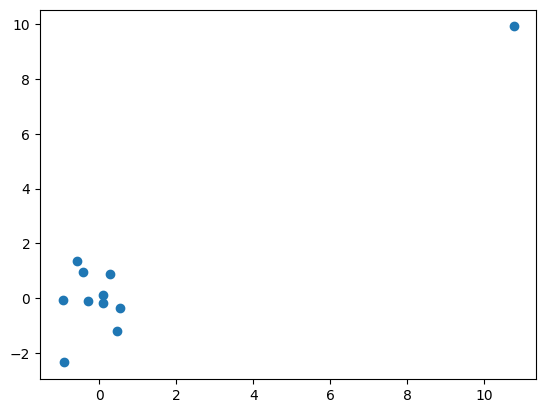

In [ ]:
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt


def linear(x, y):
    return np.einsum('ik,jk -> ij', x, y)

def RBF(sigma: float=1.):
    assert sigma>0
    def kernel(x, y):
        return np.exp(-np.sum((x-y)**2, axis=-1)/(2*sigma**2))
    return kernel

class One_class_SVM:
    def __init__(self, nu: float, kernel: Callable, *, max_iter: int=1000, epsilon=1e-6):
        assert nu>0 and nu<1, "nu should be positive"
        self.nu=nu
        self.kernel=kernel
        self.Gram=None
        self.epsilon=1e-3
        
        self.X=None #Data

        self.max_iter=max_iter

        self.epsilon=epsilon
    
    def init(self, ln: int):
        """
        Initialize Lagrange multipliers (alpha_i)_i
        ln: Amount of sample.
        """
        alpha=np.zeros(ln)
        alpha[:int(ln*self.nu)]=1/(ln*self.nu)
        alpha[int(ln*self.nu)]=1-np.sum(alpha)

        #To ensure that SV is not empty at initialization
        if np.isclose(ln*self.nu, round(ln*self.nu)):
            alpha[0]-=.1/(ln*self.nu)
            alpha[-1]+=.1/(ln*self.nu)

        (mask,)=np.where(0<alpha)
        O=self.Gram @ alpha
        rho=np.max(O[mask])
        return rho, alpha, O
    
    def KKT_violation_measure(self, C, O, rho, alpha):
        KKT_viol1=np.max(np.maximum((O-rho)*alpha, self.epsilon))
        KKT_viol2=np.max(np.maximum((rho-O)*(C - alpha), self.epsilon))
        return np.maximum(KKT_viol1, KKT_viol2)


    def fit(self, X: np.ndarray):
        self.X=np.array(X)
        ln=X.shape[0] #Amount of data
        self.Gram=self.kernel(X[:,None], X[None])
        rho, alpha, O=self.init(ln)
        assert np.isclose(np.sum(alpha), 1), "alpha should sum to 1 at initialization."

        assert self.nu*ln>=1

        C=1/(self.nu * ln)

        print(alpha)
            
        (SV, )=np.where((alpha>self.epsilon) * (alpha<C-self.epsilon))
        KKT_viol=self.KKT_violation_measure(C, O, rho, alpha)
        (idx, )=np.where(np.logical_or( ((O-rho)*alpha>0), ((rho-O)*(C - alpha)>0) ) )

        assert len(idx)>0

        assert len(SV)>0

        nb_iter=0

        while KKT_viol>self.epsilon and nb_iter<self.max_iter:
            idx1=idx[0]
            tmp=-np.ones(ln)*np.inf
            tmp[SV]=O[SV]
            idx2=np.argmax(np.abs(tmp - O[idx1]))
            Delta=alpha[idx1] + alpha[idx2]
            C1=np.sum(self.Gram[idx1]*alpha) - alpha[idx1]*self.Gram[idx1, idx1] - alpha[idx2]*self.Gram[idx1, idx2]
            C2=np.sum(self.Gram[idx2]*alpha) - alpha[idx2]*self.Gram[idx2, idx2] - alpha[idx1]*self.Gram[idx1, idx2]

            alpha_1, alpha_2=alpha[idx1], alpha[idx2]
            alpha[idx2]=Delta*(self.Gram[idx1, idx1] - self.Gram[idx1, idx2] + C1 - C2)/(self.Gram[idx1, idx1] + self.Gram[idx2, idx2] - 2*self.Gram[idx1, idx2])
            L=np.maximum(0, Delta-C)
            H=np.minimum(C, Delta)
            alpha[idx2]=np.clip(alpha[idx2], L, H)
            alpha[idx1]=Delta-alpha[idx2]


            O += self.Gram[:,idx1]*(alpha[idx1]-alpha_1) + self.Gram[:,idx2]*(alpha[idx2]-alpha_2)
            (SVp, )=np.where((alpha>self.epsilon) * (alpha<C-self.epsilon))
            if len(SVp)>0:
                SV=SVp
            (idx, )=np.where( np.logical_or( ((O-rho)*alpha>0), ((rho-O)*(C - alpha)>0) ) )
            rho=np.mean(self.Gram[SV] @ alpha)

            KKT_viol=self.KKT_violation_measure(C, O, rho, alpha)

            nb_iter+=1
        self.rho=rho
        self.alpha=alpha
    
    def decision_function(self, x):
        """
        Decision rule of the One-Class SVM.
        Args:
            x (np.ndarray). data
        Returns:
            -1 if x is an outlier, +1 otherwise.
        """
        K=self.kernel(self.X, x)
        return np.sign(K@self.alpha - self.rho + self.epsilon)

nu=.2
N=10
oc_svm=One_class_SVM(.2, RBF())
X=np.random.randn(N, 2)
X=np.concatenate((X, np.random.randn(1, 2)+10), axis=0)
print(X.shape, 1/(nu*(N+1)))
oc_svm.fit(X)

plt.scatter(X[:,0], X[:,1])
plt.show()

## ECOD